# Latent-space random walk Metropolis for alanine dipeptide

This notebook reproduces the final experiment used for the project:

```bash
python notebooks/final.py --seed 1 --latent-step 0.12 --ic-step 0.003 --n-steps 2000
```

The goal is to compare two random walk Metropolis (RWM) samplers for the Boltzmann distribution of alanine dipeptide:

1. **Direct IC RWM:** add Gaussian noise directly to internal coordinates and accept/reject with the molecular Boltzmann weight.
2. **Latent RWM:** train a normalizing flow on molecular dynamics (MD) samples, map the molecule to the flow's Gaussian latent space, run RWM there, and evaluate the Metropolis ratio after mapping back to molecular coordinates.

The important question is not only which chain has a higher local acceptance rate. For this system, the more meaningful question is whether the sampler moves between major Ramachandran basins instead of staying trapped in the initial alpha basin.


## Molecular target distribution

Alanine dipeptide is a small peptide often used as a benchmark for molecular sampling. Even though it is small, it has metastable conformational states separated by energy barriers. These states are usually visualized with a **Ramachandran plot**, whose axes are two backbone torsion angles, `phi` and `psi`.

The target distribution is the Boltzmann distribution

$$
\pi(x) \propto \exp[-U_{\mathrm{cart}}(x)],
$$

where $x$ is the Cartesian molecular configuration and $U_{\mathrm{cart}}(x)$ is the force-field energy in units of $k_BT$. A low energy structure has high probability, but the volume element also matters when we transform coordinates. We sample in internal-coordinate space $z$, so the correct internal-coordinate target is

$$
\pi_z(z) \propto \exp[-U_{\mathrm{cart}}(x(z))] \left|\det \frac{\partial x}{\partial z}\right|.
$$

Equivalently, the negative log density used in Metropolis ratios is

$$
U_{\mathrm{IC}}(z) = U_{\mathrm{cart}}(x(z)) - \log \left|\det \frac{\partial x}{\partial z}\right|.
$$

That Jacobian term is essential. Without it, the sampler targets the wrong density in internal coordinates.


In [1]:
import argparse, csv, json, math, pickle, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from matplotlib.colors import LogNorm
from torch.nn.utils import clip_grad_norm_
from tqdm.auto import tqdm

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "external" / "bgflow"))
sys.path.insert(0, str(REPO / "external" / "bgmol"))

from bgmol.datasets import Ala2TSF300
import bgflow as bg
import mdtraj as md

SEED = 1
N_CHAINS = 10
N_STEPS = 2_000
LATENT_STEP = 0.12
IC_STEP = 0.003
PRETRAIN_N = 50_000
PRETRAIN_STEPS = 10_000
BATCH = 512
LR = 3e-4
LOG_EVERY = 200
INIT_BASIN = "alpha"
INIT_POOL_SIZE = 50_000
FLOW_ROUNDS = 3
FLOW_HIDDEN = 128

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"device={DEVICE}")


/accounts/projects/yss/stephen.lu/stat238/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/accounts/projects/yss/stephen.lu/stat238/external/bgmol/bgmol/util/pkg.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


device=cuda:0


## Load MD data and build internal coordinates

The dataset contains one million MD frames of alanine dipeptide. Each frame has 22 atoms in Cartesian coordinates. We convert these coordinates into a 60-dimensional mixed internal-coordinate representation:

- bond lengths,
- bond angles,
- torsion angles,
- a small set of whitened Cartesian degrees of freedom for the rigid block.

This representation is much better suited for molecular sampling than adding noise independently to all Cartesian atom positions, because bond and angle constraints are built into the coordinate system.


In [2]:
root = REPO / "data"
dataset = Ala2TSF300(root=str(root), download=not (root / "Ala2TSF300.npy").is_file(), read=True)
system = dataset.system
coordinates = dataset.coordinates
target_energy = dataset.get_energy_model(n_workers=16)

ctx = torch.zeros([], device=DEVICE, dtype=DTYPE)
dim = dataset.dim
dim_bonds = len(system.z_matrix)
dim_angles = dim_bonds
dim_torsions = dim_bonds
dim_fixed = len(system.rigid_block) * 3 - 6
dim_ics = dim_bonds + dim_angles + dim_torsions + dim_fixed
bounded_dim = dim_bonds + dim_angles + dim_torsions

all_data = torch.from_numpy(coordinates).to(ctx).reshape(-1, dim)
coordinate_transform = bg.MixedCoordinateTransformation(
    data=all_data,
    z_matrix=system.z_matrix,
    fixed_atoms=system.rigid_block,
    keepdims=dim_fixed,
    normalize_angles=True,
).to(ctx)

def cart_to_ic(x):
    b, a, t, c, _ = coordinate_transform.forward(x)
    return torch.cat([b, a, t, c], dim=-1)

def ic_to_cart(z):
    b, a, t = dim_bonds, dim_angles, dim_torsions
    x, _ = coordinate_transform.forward(
        z[:, :b], z[:, b:b+a], z[:, b+a:b+a+t], z[:, b+a+t:], inverse=True
    )
    return x

def ic_to_cart_with_logdet(z):
    b, a, t = dim_bonds, dim_angles, dim_torsions
    x, dlogp = coordinate_transform.forward(
        z[:, :b], z[:, b:b+a], z[:, b+a:b+a+t], z[:, b+a+t:], inverse=True
    )
    return x, dlogp.squeeze(-1)

with torch.no_grad():
    all_ics = cart_to_ic(all_data)
print(f"MD frames: {len(all_data):,}; IC shape: {tuple(all_ics.shape)}")


Using downloaded and verified file: /tmp/alanine-dipeptide-nowater.pdb


/accounts/projects/yss/stephen.lu/stat238/external/bgflow/bgflow/distribution/energy/openmm.py:200: UserWarning: It looks like you are using an OpenMMBridge with multiple workers in an ipython environment. This can behave a bit silly upon KeyboardInterrupt (e.g., kill the stdout stream). If you experience any issues, consider initializing the bridge with n_workers=1 in ipython/jupyter.
  warnings.warn(


MD frames: 1,000,000; IC shape: (1000000, 60)


## Normalizing flow model

The normalizing flow is trained by maximum likelihood on MD samples in internal-coordinate space. It provides an invertible map between a simple latent variable and molecular internal coordinates.

The base variable for the bgflow spline layers is uniform on `(0, 1)`. For the latent RWM experiment, we use a standard Gaussian latent `r` and transform it through the Gaussian CDF, `u = Phi(r)`, before applying the flow. This lets us do random walk proposals in an unconstrained Gaussian space.

The architecture uses conditional rational-quadratic spline couplings from `bgflow`:

- torsions are coupled with fixed coordinates,
- fixed coordinates are coupled with torsions,
- bonds are coupled with angles,
- angles are coupled with bonds,
- bgflow internal-coordinate marginals handle bounded and periodic coordinate structure.

This is more appropriate than a plain RealNVP on raw internal coordinates because molecular coordinates have bounded bond/angle dimensions and periodic torsions.


In [3]:
class _Clamped(nn.Module):
    def __init__(self, net, c=8.0):
        super().__init__(); self.net, self.c = net, c
    def forward(self, x):
        return self.net(x).clamp(-self.c, self.c)

def _identity_init(flow):
    from bgflow.nn.flow.transformer.spline import ConditionalSplineTransformer
    from bgflow.nn.periodic import WrapPeriodic
    slope_bias = math.log(math.exp(1.0 - 1e-3) - 1.0)
    for m in flow.modules():
        if not isinstance(m, ConditionalSplineTransformer):
            continue
        net = m._params_net.net if hasattr(m._params_net, "net") else m._params_net
        net = net.net if isinstance(net, WrapPeriodic) else net
        if not (hasattr(net, "_layers") and isinstance(net._layers[-1], nn.Linear)):
            continue
        last = net._layers[-1]
        y_dim = len(m._is_circular)
        n_noncirc = int((~m._is_circular).sum().item())
        n_bins = (last.out_features - n_noncirc) // (3 * y_dim)
        bias = torch.zeros(last.out_features)
        bias[2*n_bins*y_dim:3*n_bins*y_dim] = slope_bias
        bias[3*n_bins*y_dim:] = slope_bias
        with torch.no_grad():
            last.weight.zero_(); last.bias.copy_(bias.to(last.bias.device))

class FlowIC(nn.Module):
    def __init__(self, coordinate_transform, z_md=None, n_rounds=3, hidden=128, num_bins=8):
        super().__init__()
        from bgflow.factory.tensor_info import BONDS, ANGLES, TORSIONS, FIXED, ShapeDictionary
        from bgflow.factory.conditioner_factory import make_conditioners
        from bgflow.factory.icmarginals import InternalCoordinateMarginals
        from bgflow.distribution.normal import TruncatedNormalDistribution
        from bgflow.nn.flow.sequential import SequentialFlow
        from bgflow.nn.flow.coupling import CouplingFlow, WrapFlow
        from bgflow.nn.flow.transformer.spline import ConditionalSplineTransformer
        from bgflow.nn.flow.cdf import CDFTransform
        from bgflow.nn.flow.inverted import InverseFlow
        from bgflow.nn.flow.base import Flow

        shape_info = ShapeDictionary.from_coordinate_transform(coordinate_transform)
        flow_ctx = {"device": DEVICE, "dtype": DTYPE}

        def coupling(what, on):
            c = make_conditioners(
                transformer_type=ConditionalSplineTransformer,
                what=(what,), on=(on,), shape_info=shape_info,
                num_bins=num_bins, hidden=(hidden, hidden),
            )
            tx = ConditionalSplineTransformer(
                params_net=_Clamped(c["params_net"]),
                is_circular=torch.tensor(shape_info.is_circular((what,))),
            )
            return CouplingFlow(tx, [shape_info.index(what)], [shape_info.index(on)]).to(**flow_ctx)

        layers = []
        for _ in range(n_rounds):
            layers += [coupling(TORSIONS, FIXED), coupling(FIXED, TORSIONS)]
        for _ in range(n_rounds):
            layers += [coupling(BONDS, ANGLES), coupling(ANGLES, BONDS)]

        ic_marg = InternalCoordinateMarginals(shape_info, flow_ctx, fixed_scale=1.0)
        if z_md is not None:
            for field, slc in [(BONDS, slice(0, dim_bonds)), (ANGLES, slice(dim_bonds, dim_bonds + dim_angles))]:
                vals = z_md[:, slc]
                mu = vals.mean(0).to(**flow_ctx)
                sig = torch.full((vals.shape[1],), float(vals.std().clamp(min=0.02).item()), **flow_ctx)
                ic_marg[field] = TruncatedNormalDistribution(
                    mu=mu, sigma=sig,
                    lower_bound=torch.as_tensor(0.01, **flow_ctx),
                    upper_bound=torch.as_tensor(1.0, **flow_ctx),
                )
        for field in [BONDS, ANGLES, TORSIONS, FIXED]:
            if field in ic_marg:
                d = ic_marg[field]
                layers.append(WrapFlow(d if isinstance(d, Flow) else InverseFlow(CDFTransform(d)), (shape_info.index(field),)))

        self.flow = SequentialFlow(layers).to(**flow_ctx)
        self.register_buffer("_dev", torch.zeros(1, **flow_ctx))
        _identity_init(self.flow)

    def _split(self, z):
        b, a, t = dim_bonds, dim_angles, dim_torsions
        return z[:, :b], z[:, b:b+a], z[:, b+a:b+a+t], z[:, b+a+t:]
    def forward(self, u):
        *x, dlogp = self.flow.forward(*self._split(u), inverse=False)
        return torch.cat(x, dim=-1), dlogp.squeeze(-1)
    def inverse(self, x):
        *u, dlogp = self.flow.forward(*self._split(x), inverse=True)
        return torch.cat(u, dim=-1), dlogp.squeeze(-1)
    def nll(self, x):
        return -self.inverse(x)[1]
    @torch.no_grad()
    def sample(self, n):
        u = torch.rand(n, dim_ics, device=self._dev.device, dtype=self._dev.dtype).clamp(1e-6, 1 - 1e-6)
        return self.forward(u)[0]


## Target density and diagnostics

The `ICEnergy` class is the target negative log density in internal coordinates. It includes the coordinate-transform Jacobian, so Metropolis ratios are computed in the correct space.

The main diagnostic is the basin label from the Ramachandran angles:

- `alpha`: `phi < 0`, `psi < 0`,
- `beta`: `phi < 0`, `psi >= 0`,
- `right`: the remaining right-handed basin.

We initialize all chains from MD samples in the alpha basin. The plotted quantity `not alpha` therefore measures whether a chain escapes the starting basin.


In [4]:
normal = torch.distributions.Normal(torch.tensor(0.0, device=DEVICE), torch.tensor(1.0, device=DEVICE))
BASIN_NAMES = ("alpha", "beta", "right")
BASIN_TO_ID = {name: i for i, name in enumerate(BASIN_NAMES)}

class ICEnergy:
    def U(self, z):
        x, log_det_dx_dz = ic_to_cart_with_logdet(z)
        return target_energy.energy(x).squeeze(-1) - log_det_dx_dz
ic_energy = ICEnergy()

def valid_ic(z, eps=1e-6):
    b = z[:, :bounded_dim]
    return torch.isfinite(z).all(-1) & (b > eps).all(-1) & (b < 1 - eps).all(-1)

def phi_psi(z):
    with torch.no_grad():
        x = ic_to_cart(z).cpu().numpy()
    return system.compute_phi_psi(md.Trajectory(xyz=x.reshape(-1, 22, 3), topology=system.mdtraj_topology))

def basin_ids(phi, psi):
    labels = np.full(np.asarray(phi).shape, BASIN_TO_ID["right"], dtype=np.int64)
    labels[(phi < 0) & (psi < 0)] = BASIN_TO_ID["alpha"]
    labels[(phi < 0) & (psi >= 0)] = BASIN_TO_ID["beta"]
    return labels

def fractions(labels):
    flat = np.asarray(labels).reshape(-1)
    return {name: float((flat == i).mean()) for i, name in enumerate(BASIN_NAMES)}

def tv(labels, ref):
    a, b = np.array(list(fractions(labels).values())), np.array(list(fractions(ref).values()))
    return float(0.5 * np.abs(a - b).sum())

def autocorr_1d(x, max_lag):
    x = np.asarray(x, dtype=float) - np.asarray(x, dtype=float).mean()
    var = np.dot(x, x) / len(x)
    if var == 0:
        return None
    out = np.empty(max_lag + 1); out[0] = 1.0
    for lag in range(1, max_lag + 1):
        out[lag] = np.dot(x[:-lag], x[lag:]) / ((len(x) - lag) * var)
    return out

def acf_and_ess(x, max_lag):
    acfs, ess_total = [], 0.0
    for c in range(x.shape[1]):
        acf = autocorr_1d(x[:, c], max_lag)
        if acf is None:
            continue
        acfs.append(acf)
        pos = []
        for v in acf[1:]:
            if v <= 0:
                break
            pos.append(v)
        ess_total += x.shape[0] / max(1.0 + 2.0 * float(np.sum(pos)), 1.0)
    if not acfs:
        acf = np.zeros(max_lag + 1); acf[0] = 1.0
        return acf, 0.0, 0
    return np.mean(acfs, axis=0), ess_total, len(acfs)

def smooth(x, w=200):
    x = np.asarray(x, dtype=float)
    return x if len(x) < w else np.convolve(x, np.ones(w) / w, mode="valid")


## Train or load the flow

The flow is trained by maximum likelihood on 50,000 MD internal-coordinate samples. The checkpoint is reused on future runs, so the notebook does not retrain unless the checkpoint is missing.

The validation energy printed here is useful because it gives a scale for plausible molecular samples. Flow samples with much larger corrected internal-coordinate energy are formally valid but unlikely under the Boltzmann target.


In [5]:
def evaluate_flow(flow, z_val, n_samples=1000):
    z_s = flow.sample(n_samples)
    valid = valid_ic(z_s)
    out = {"nll_val": float(flow.nll(z_val).mean().item()), "flow_valid": float(valid.float().mean().item())}
    if valid.any():
        U = ic_energy.U(z_s[valid])
        out.update(flow_U_median=float(U.median().item()), flow_U_q95=float(torch.quantile(U, 0.95).item()))
    return out

def pretrain(flow, z_train, z_val, steps, batch, lr, log_every):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps, eta_min=lr * 1e-2)
    hist = []
    print(f"Pre-training flow: {steps} steps")
    print(f"{'step':>6} | {'nll_train':>10} | {'nll_val':>10} | {'U_med':>8} | {'U_q95':>8}")
    for s in range(1, steps + 1):
        idx = torch.randint(len(z_train), (batch,), device=z_train.device)
        loss = flow.nll(z_train[idx]).mean()
        opt.zero_grad(); loss.backward(); clip_grad_norm_(flow.parameters(), 10.0); opt.step(); sched.step()
        if s == 1 or s % log_every == 0 or s == steps:
            row = {"step": s, "nll_train": float(loss.item()), **evaluate_flow(flow, z_val)}
            hist.append(row)
            print(f"{s:6d} | {row['nll_train']:10.1f} | {row['nll_val']:10.1f} | {row.get('flow_U_median', np.nan):8.1f} | {row.get('flow_U_q95', np.nan):8.1f}")
    return hist

def save_ckpt(path, flow, meta, history):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"model": flow.state_dict(), "meta": meta, "history": history}, path)

def load_ckpt(path, flow, meta):
    if not path.is_file():
        return None
    ckpt = torch.load(path, map_location=DEVICE)
    if ckpt.get("meta") != meta:
        return None
    flow.load_state_dict(ckpt["model"])
    return ckpt.get("history", [])

perm = torch.randperm(len(all_ics), device=DEVICE)
z_train = all_ics[perm[:PRETRAIN_N]]
z_val = all_ics[perm[PRETRAIN_N:PRETRAIN_N + 1000]]
z_pool = all_ics[perm[PRETRAIN_N + 1000:PRETRAIN_N + 1000 + INIT_POOL_SIZE]]

with torch.no_grad():
    U_val = ic_energy.U(z_val)
print(f"Validation MD corrected IC energy: median={U_val.median().item():.1f}, q95={torch.quantile(U_val, 0.95).item():.1f}")

flow_kw = {"n_rounds": FLOW_ROUNDS, "hidden": FLOW_HIDDEN, "num_bins": 8}
flow = FlowIC(coordinate_transform, z_md=z_train, **flow_kw)
meta = {
    "script": "final.py", "profile": "full", "seed": SEED,
    "pretrain_n": PRETRAIN_N, "pretrain_steps": PRETRAIN_STEPS,
    "batch": BATCH, "lr": LR, "target_energy": "cartesian_minus_logdet_dx_dz", **flow_kw,
}
ckpt_path = REPO / "notebooks" / "checkpoints" / f"flow_final_full_seed{SEED}.pt"
history = load_ckpt(ckpt_path, flow, meta)
if history is None:
    history = pretrain(flow, z_train, z_val, PRETRAIN_STEPS, BATCH, LR, LOG_EVERY)
    save_ckpt(ckpt_path, flow, meta, history)
    print(f"Saved checkpoint: {ckpt_path}")
else:
    print(f"Loaded checkpoint: {ckpt_path}")
flow.eval()
print("Flow eval:", evaluate_flow(flow, z_val, n_samples=2000))


Validation MD corrected IC energy: median=44.5, q95=54.0


/accounts/projects/yss/stephen.lu/stat238/external/bgflow/bgflow/nn/flow/transformer/spline.py:80: UserWarning: your nflows version does not support 'enable_identity_init'.See https://github.com/bayesiains/nflows/pull/65
  warnings.warn(


Loaded checkpoint: /accounts/projects/yss/stephen.lu/stat238/notebooks/checkpoints/flow_final_full_seed1.pt
Flow eval: {'nll_val': -230.14004516601562, 'flow_valid': 1.0, 'flow_U_median': 54.07207489013672, 'flow_U_q95': 77.361572265625}


## Choose initial chains from the same alpha basin

To make the comparison meaningful, both samplers start from exactly the same held-out MD configurations. We filter the held-out MD pool to the alpha basin and draw 10 starting structures from that set.

This deliberately creates a metastability test: a sampler that only makes small local moves should have difficulty leaving alpha, while a good latent proposal geometry may cross into another basin more easily.


In [6]:
p_phi, p_psi = phi_psi(z_pool)
pool_labels = basin_ids(p_phi, p_psi)
candidates = np.flatnonzero(pool_labels == BASIN_TO_ID[INIT_BASIN])
chosen = np.random.choice(candidates, N_CHAINS, replace=len(candidates) < N_CHAINS)
z_init = z_pool[torch.as_tensor(chosen, device=DEVICE)]
init_phi, init_psi = phi_psi(z_init)
print(f"Initial source: held-out MD samples")
print(f"Requested basin: {INIT_BASIN}; matches in pool: {len(candidates)}/{len(z_pool)}")
print("Initial basin fractions:", fractions(basin_ids(init_phi, init_psi)))


Initial source: held-out MD samples
Requested basin: alpha; matches in pool: 14354/50000
Initial basin fractions: {'alpha': 1.0, 'beta': 0.0, 'right': 0.0}


## Two random walk Metropolis kernels

### Direct IC RWM

The direct baseline proposes

$$
z' = z + \sigma_{IC}\epsilon, \quad \epsilon \sim \mathcal{N}(0, I),
$$

then accepts with probability

$$
\min\{1, \exp[-U_{IC}(z') + U_{IC}(z)]\}.
$$

### Latent RWM

The latent chain lives in Gaussian space $r$. A proposal is

$$
r' = r + \sigma_{latent}\epsilon.
$$

We map $r'$ through $u' = \Phi(r')$ and then through the flow to get an internal-coordinate sample $z' = f(u')$. The Metropolis log target in latent space is

$$
\log \pi_r(r) = -U_{IC}(f(\Phi(r))) + \log\left|\det\frac{\partial f}{\partial u}\right| + \sum_i \log \mathcal{N}(r_i;0,1).
$$

The last two terms are the change-of-variables correction from Gaussian latent space to internal-coordinate space. With this correction, latent RWM is still an ordinary Metropolis sampler targeting the same Boltzmann distribution.


In [7]:
@torch.no_grad()
def latent_from_ic(flow, x):
    u, _ = flow.inverse(x)
    return normal.icdf(u.clamp(1e-6, 1 - 1e-6)).clamp(-8.0, 8.0)

@torch.no_grad()
def latent_logp(flow, r):
    u = normal.cdf(r).clamp(1e-6, 1 - 1e-6)
    x, logdet_flow = flow.forward(u)
    valid = valid_ic(x)
    logp = torch.full((len(r),), -torch.inf, device=r.device, dtype=r.dtype)
    if valid.any():
        logdet_cdf = normal.log_prob(r[valid]).sum(-1)
        logp[valid] = -ic_energy.U(x[valid]) + logdet_flow[valid] + logdet_cdf
    return logp, x

@torch.no_grad()
def run_latent_rwm(flow, x0, n_steps, step):
    r = latent_from_ic(flow, x0)
    logp, x = latent_logp(flow, r)
    traj, accs = [], []
    for s in tqdm(range(n_steps), desc="Latent RWM"):
        rp = r + step * torch.randn_like(r)
        logp_p, x_p = latent_logp(flow, rp)
        acc = torch.log(torch.rand(len(r), device=DEVICE)) < (logp_p - logp).clamp(max=0.0)
        r, logp, x = torch.where(acc[:, None], rp, r), torch.where(acc, logp_p, logp), torch.where(acc[:, None], x_p, x)
        traj.append(x.clone()); accs.append(acc)
    return torch.stack(traj), torch.stack(accs)

@torch.no_grad()
def run_ic_rwm(x0, n_steps, step):
    x, U_x = x0.clone(), ic_energy.U(x0)
    traj, accs = [], []
    for s in tqdm(range(n_steps), desc="IC RWM"):
        xp = x + step * torch.randn_like(x)
        valid = valid_ic(xp)
        U_p = torch.full_like(U_x, torch.inf)
        if valid.any():
            U_p[valid] = ic_energy.U(xp[valid])
        acc = torch.log(torch.rand(len(x), device=DEVICE)) < (U_x - U_p).clamp(max=0.0)
        x, U_x = torch.where(acc[:, None], xp, x), torch.where(acc, U_p, U_x)
        traj.append(x.clone()); accs.append(acc)
    return torch.stack(traj), torch.stack(accs)


## Run the experiment

The settings below match the command at the top of the notebook. We time both samplers because latent RWM is computationally more expensive per step: every proposal requires a flow evaluation and an energy evaluation after transforming back to internal coordinates.


In [8]:
t0 = time.perf_counter()
traj_latent, acc_latent = run_latent_rwm(flow, z_init, N_STEPS, LATENT_STEP)
time_latent = time.perf_counter() - t0

t0 = time.perf_counter()
traj_ic, acc_ic = run_ic_rwm(z_init, N_STEPS, IC_STEP)
time_ic = time.perf_counter() - t0

print(f"Latent RWM: acceptance={acc_latent.float().mean().item():.3f}, seconds={time_latent:.1f}")
print(f"IC RWM:     acceptance={acc_ic.float().mean().item():.3f}, seconds={time_ic:.1f}")


IC RWM: 100%|██████████| 2000/2000 [00:58<00:00, 34.41it/s]

Latent RWM: acceptance=0.077, seconds=111.7
IC RWM:     acceptance=0.143, seconds=58.2


## Convert trajectories to Ramachandran coordinates

The full chain is 60-dimensional, so we project samples onto the two backbone angles `phi` and `psi`. This is the standard qualitative diagnostic for alanine dipeptide because the main metastable states are visible in this two-dimensional plot.


In [9]:
def traj_phi_psi(traj):
    S, C, _ = traj.shape
    p, q = phi_psi(traj.reshape(-1, dim_ics))
    return p.reshape(S, C), q.reshape(S, C)

phi_lat, psi_lat = traj_phi_psi(traj_latent)
phi_ic, psi_ic = traj_phi_psi(traj_ic)
ref_x = all_data[torch.randperm(len(all_data), device=DEVICE)[:50_000]].cpu().numpy().reshape(-1, 22, 3)
phi_ref, psi_ref = system.compute_phi_psi(md.Trajectory(xyz=ref_x, topology=system.mdtraj_topology))

labels_lat = basin_ids(phi_lat, psi_lat)
labels_ic = basin_ids(phi_ic, psi_ic)
labels_ref = basin_ids(phi_ref, psi_ref)
indicator_name = f"not {INIT_BASIN}"
init_id = BASIN_TO_ID[INIT_BASIN]
indicator_lat = (labels_lat != init_id).astype(float)
indicator_ic = (labels_ic != init_id).astype(float)
indicator_ref = (labels_ref != init_id).astype(float)

max_lag = min(500, N_STEPS - 1)
acf_lat, ess_lat, var_chains_lat = acf_and_ess(indicator_lat, max_lag)
acf_ic, ess_ic, var_chains_ic = acf_and_ess(indicator_ic, max_lag)

summary = {
    "latent_acceptance": float(acc_latent.float().mean().item()),
    "ic_acceptance": float(acc_ic.float().mean().item()),
    "latent_seconds": time_latent,
    "ic_seconds": time_ic,
    "latent_mode_ess": ess_lat,
    "ic_mode_ess": ess_ic,
    "latent_mode_ess_per_sec": ess_lat / time_latent,
    "ic_mode_ess_per_sec": ess_ic / time_ic,
    "latent_variable_chains": var_chains_lat,
    "ic_variable_chains": var_chains_ic,
    "latent_basin_fractions": fractions(labels_lat),
    "ic_basin_fractions": fractions(labels_ic),
    "md_basin_fractions": fractions(labels_ref),
    "latent_basin_tv_to_md": tv(labels_lat, labels_ref),
    "ic_basin_tv_to_md": tv(labels_ic, labels_ref),
}
summary


{'latent_acceptance': 0.07684999704360962,
 'ic_acceptance': 0.14319999516010284,
 'latent_seconds': 111.69860504195094,
 'ic_seconds': 58.1675617583096,
 'latent_mode_ess': 1432.9113831233533,
 'ic_mode_ess': 15.352067924019423,
 'latent_mode_ess_per_sec': 12.828373125923918,
 'ic_mode_ess_per_sec': 0.2639283384063504,
 'latent_variable_chains': 8,
 'ic_variable_chains': 1,
 'latent_basin_fractions': {'alpha': 0.7559, 'beta': 0.2441, 'right': 0.0},
 'ic_basin_fractions': {'alpha': 0.9831, 'beta': 0.0169, 'right': 0.0},
 'md_basin_fractions': {'alpha': 0.28606, 'beta': 0.68176, 'right': 0.03218},
 'latent_basin_tv_to_md': 0.46984000000000004,
 'ic_basin_tv_to_md': 0.69704}

## Main qualitative result: Ramachandran coverage

The MD reference shows the equilibrium basin structure. Since both samplers start in alpha, good performance means leaving alpha and moving toward the MD basin fractions.

A direct IC random walk can have a reasonable local acceptance rate but still remain trapped, because accepted moves are small in the coordinates that matter for crossing torsional barriers. The latent chain can have lower local acceptance and higher cost per step, but it may explore the Ramachandran basins more effectively.


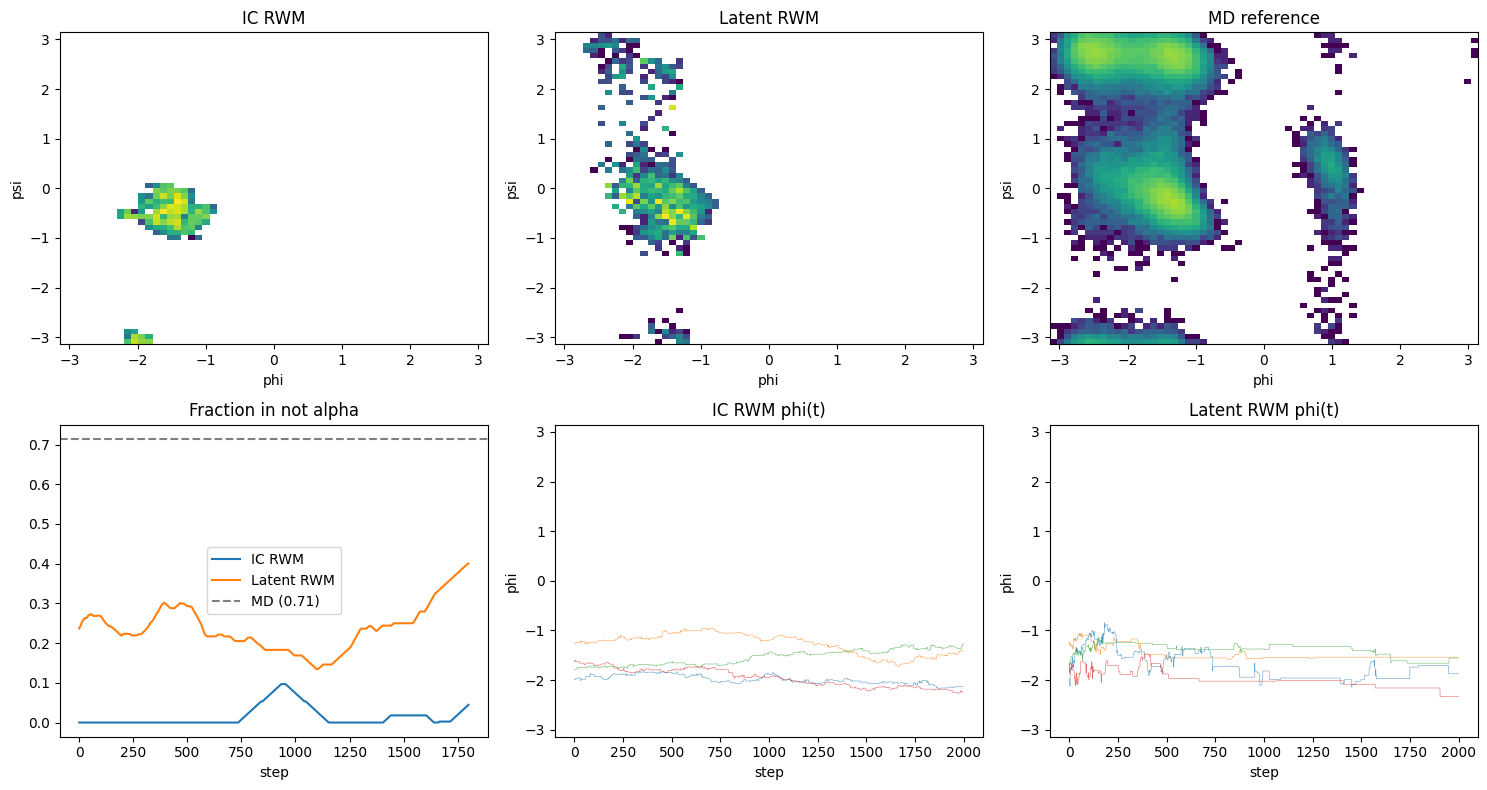

In [10]:
rama_kw = dict(bins=60, norm=LogNorm(), range=[[-math.pi, math.pi], [-math.pi, math.pi]])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, p, q, title in [
    (axes[0, 0], phi_ic.flatten(), psi_ic.flatten(), "IC RWM"),
    (axes[0, 1], phi_lat.flatten(), psi_lat.flatten(), "Latent RWM"),
    (axes[0, 2], phi_ref, psi_ref, "MD reference"),
]:
    ax.hist2d(p, q, **rama_kw)
    ax.set_xlabel("phi"); ax.set_ylabel("psi"); ax.set_title(title)

f_ic, f_lat, f_ref = indicator_ic.mean(axis=1), indicator_lat.mean(axis=1), float(indicator_ref.mean())
axes[1, 0].plot(smooth(f_ic), label="IC RWM")
axes[1, 0].plot(smooth(f_lat), label="Latent RWM")
axes[1, 0].axhline(f_ref, color="k", linestyle="--", alpha=0.5, label=f"MD ({f_ref:.2f})")
axes[1, 0].set_title(f"Fraction in {indicator_name}"); axes[1, 0].set_xlabel("step"); axes[1, 0].legend()
for c in range(min(4, phi_ic.shape[1])):
    axes[1, 1].plot(phi_ic[:, c], lw=0.4, alpha=0.7)
    axes[1, 2].plot(phi_lat[:, c], lw=0.4, alpha=0.7)
axes[1, 1].set_title("IC RWM phi(t)"); axes[1, 2].set_title("Latent RWM phi(t)")
for ax in axes[1, 1:]:
    ax.set_xlabel("step"); ax.set_ylabel("phi"); ax.set_ylim(-math.pi, math.pi)
plt.tight_layout()
plt.show()


## Quantitative diagnostics

The ESS calculation below is intentionally based on the `not alpha` mode indicator, not on every coordinate independently. This measures the effective number of mode-transition samples. A chain that never leaves alpha has a constant indicator, so it contributes zero mode ESS. This avoids the misleading situation where a completely stuck chain appears to have excellent ESS because its indicator has no variance.

The ACF plot shows how persistent the mode indicator is after a chain starts visiting other basins. The bar plot reports mode ESS per second, which includes wall-clock cost.


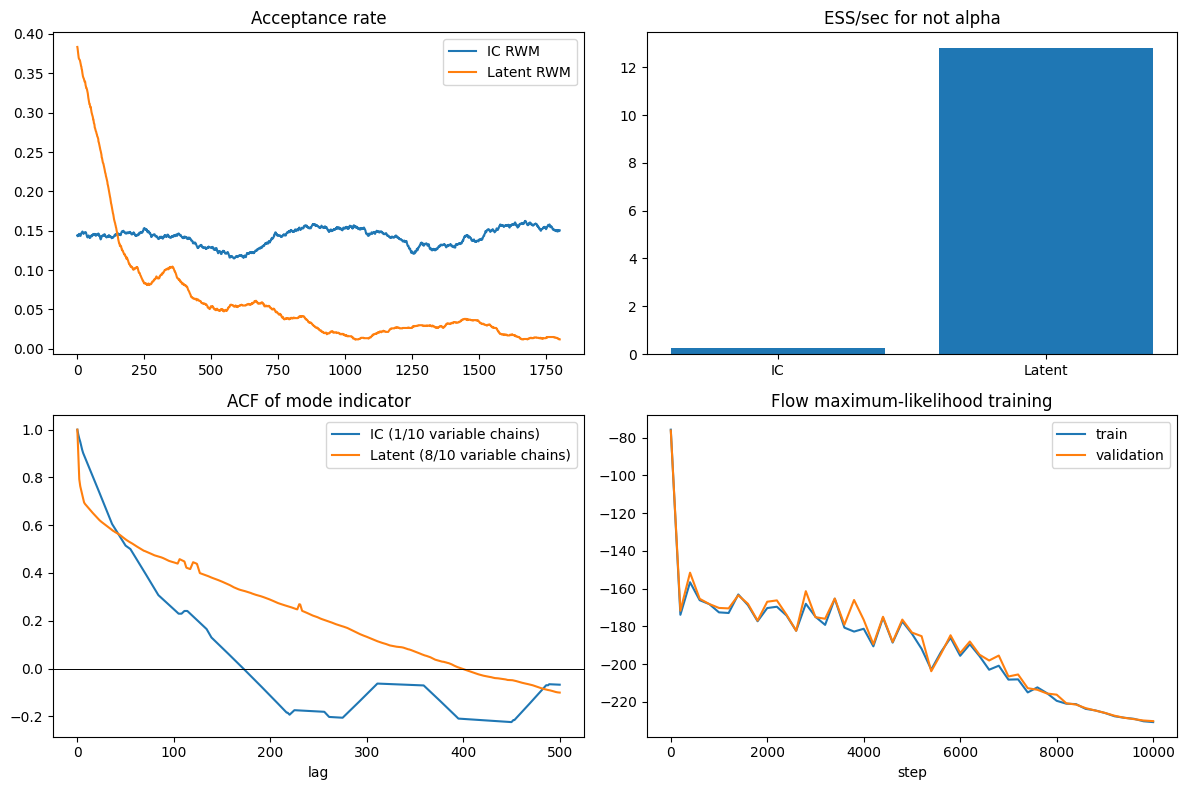

{
  "latent_acceptance": 0.07684999704360962,
  "ic_acceptance": 0.14319999516010284,
  "latent_seconds": 111.69860504195094,
  "ic_seconds": 58.1675617583096,
  "latent_mode_ess": 1432.9113831233533,
  "ic_mode_ess": 15.352067924019423,
  "latent_mode_ess_per_sec": 12.828373125923918,
  "ic_mode_ess_per_sec": 0.2639283384063504,
  "latent_variable_chains": 8,
  "ic_variable_chains": 1,
  "latent_basin_fractions": {
    "alpha": 0.7559,
    "beta": 0.2441,
    "right": 0.0
  },
  "ic_basin_fractions": {
    "alpha": 0.9831,
    "beta": 0.0169,
    "right": 0.0
  },
  "md_basin_fractions": {
    "alpha": 0.28606,
    "beta": 0.68176,
    "right": 0.03218
  },
  "latent_basin_tv_to_md": 0.46984000000000004,
  "ic_basin_tv_to_md": 0.69704
}


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(smooth(acc_ic.float().mean(1).cpu().numpy(), 200), label="IC RWM")
axes[0, 0].plot(smooth(acc_latent.float().mean(1).cpu().numpy(), 200), label="Latent RWM")
axes[0, 0].set_title("Acceptance rate"); axes[0, 0].legend()

axes[0, 1].bar(["IC", "Latent"], [summary["ic_mode_ess_per_sec"], summary["latent_mode_ess_per_sec"]])
axes[0, 1].set_title(f"ESS/sec for {indicator_name}")

axes[1, 0].plot(np.arange(max_lag + 1), acf_ic, label=f"IC ({var_chains_ic}/{N_CHAINS} variable chains)")
axes[1, 0].plot(np.arange(max_lag + 1), acf_lat, label=f"Latent ({var_chains_lat}/{N_CHAINS} variable chains)")
axes[1, 0].axhline(0, color="k", lw=0.7)
axes[1, 0].set_title("ACF of mode indicator"); axes[1, 0].set_xlabel("lag"); axes[1, 0].legend()

if history:
    steps = [r["step"] for r in history]
    axes[1, 1].plot(steps, [r["nll_train"] for r in history], label="train")
    axes[1, 1].plot(steps, [r["nll_val"] for r in history], label="validation")
    axes[1, 1].set_title("Flow maximum-likelihood training"); axes[1, 1].set_xlabel("step"); axes[1, 1].legend()
plt.tight_layout()
plt.show()

print(json.dumps(summary, indent=2))


## Interpreting the expected outcome

For the settings in this notebook, the direct IC RWM baseline often has a higher local acceptance probability because it proposes very small moves. However, that does not imply better sampling. If the IC chain remains in alpha, its Ramachandran coverage is poor and its `not alpha` mode ESS should be zero or very small.

The latent RWM sampler is usually slower per step and may have lower acceptance, but the flow changes the proposal geometry. A random walk in latent space can correspond to a structured, collective move in molecular internal coordinates. The positive result to look for is therefore:

- latent RWM visits non-alpha basins while IC RWM remains mostly alpha,
- latent basin fractions are closer to the MD reference,
- latent mode ESS is nonzero for several chains,
- Ramachandran plots show broader qualitative coverage.

This does not mean the flow perfectly solves sampling. The flow is trained from finite MD data and its samples can still have higher energy than true equilibrium samples. The result is best interpreted as evidence that the learned latent coordinate system improves global exploration compared with a naive local random walk in internal-coordinate space.
